Valerie Jimenez and Trevor (mon and wed)
Polynomial 3 Kernel Run classification
https://www.kaggle.com/datasets/erdemtaha/cancer-data  

In [110]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [111]:
df=pd.read_csv('Cancer_Data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [112]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [113]:
df.drop(columns=['Unnamed: 32', 'id', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se',], inplace=True)
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [114]:
print("=" * 60)
print("Cancer Stats")
print("=" * 60)

Cancer Stats


In [115]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode 'cell_type' (target variable)
df['diagnosis'] = le.fit_transform(df['diagnosis'])
class_names = le.classes_

In [116]:
X = df[[
    # Mean group
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    # Worst group
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']]

y = df['diagnosis']  # M = Malignant, B = Benign

In [117]:
# Print basic information about the dataset
print("=" * 60)
print("CANCER DATASET INFORMATION")
print("=" * 60)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Class names: {class_names}")
print(f"Classes in dataset: Class M: Malignant Cancer {sum(y==0)}, Class B: Benign Cancer {sum(y==1)}")

CANCER DATASET INFORMATION
Number of samples: 569
Number of features: 20
Class names: ['B' 'M']
Classes in dataset: Class M: Malignant Cancer 357, Class B: Benign Cancer 212


In [118]:
# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)

In [119]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Learn scaling from training data
X_test_scaled = scaler.transform(X_test) # Apply same scaling to test data

In [120]:
print("\n" + "=" * 60)
print("Testing Different SVM Kernels")
print("=" * 60)


Testing Different SVM Kernels


In [121]:

# Kernel 1: LINEAR kernel (draws straight lines)
print("\n1. LINEAR Kernel:")
print(" - Uses straight lines to separate classes")
print(" - Fast and simple")
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f" - Accuracy: {accuracy_linear * 100:.2f}%")




1. LINEAR Kernel:
 - Uses straight lines to separate classes
 - Fast and simple
 - Accuracy: 98.25%


In [122]:
# Kernel 2: RBF kernel (draws circular/curved boundaries)
print("\n2. RBF Kernel:")
print(" - Uses circular/curved boundaries to separate classes")
print(" - More flexible than linear")
print(" - gamma='scale' means it auto-adjusts to your data")
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f" - Accuracy: {accuracy_rbf * 100:.2f}%")


2. RBF Kernel:
 - Uses circular/curved boundaries to separate classes
 - More flexible than linear
 - gamma='scale' means it auto-adjusts to your data
 - Accuracy: 98.25%


In [123]:
# Kernel 3: POLYNOMIAL kernel (draws polynomial curves)
print("\n3. POLYNOMIAL Kernel (degree=3):")
print(" - Uses polynomial curves (like parabolas) to separate classes")
print(" - degree=3 means it can make S-shaped curves")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f" - Accuracy: {accuracy_poly * 100:.2f}%")


3. POLYNOMIAL Kernel (degree=3):
 - Uses polynomial curves (like parabolas) to separate classes
 - degree=3 means it can make S-shaped curves
 - Accuracy: 91.23%


In [124]:
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Linear kernel: {accuracy_linear * 100:.2f}%")
print(f"RBF kernel: {accuracy_rbf * 100:.2f}%")
print(f"Polynomial kernel: {accuracy_poly * 100:.2f}%")
# Determine which kernel performed best
accuracies = {
'Linear': accuracy_linear,
'RBF': accuracy_rbf,
'Polynomial': accuracy_poly
}
best_kernel = max(accuracies, key=accuracies.get)
print(f"\nBest performing kernel: {best_kernel}")


RESULTS SUMMARY
Linear kernel: 98.25%
RBF kernel: 98.25%
Polynomial kernel: 91.23%

Best performing kernel: Linear


In [125]:
# DETAILED REPORT FOR BEST KERNEL
# ============================================================
print("\n" + "=" * 60)
print(f"DETAILED CLASSIFICATION REPORT ({best_kernel} Kernel)")
print("=" * 60)
# Show detailed report for the best kernel
if best_kernel == 'Linear':
  print(classification_report(y_test, y_pred_linear, target_names=class_names))
elif best_kernel == 'RBF':
  print(classification_report(y_test, y_pred_rbf, target_names=class_names))
else:
  print(classification_report(y_test, y_pred_rbf, target_names=class_names))


DETAILED CLASSIFICATION REPORT (Linear Kernel)
              precision    recall  f1-score   support

           B       0.98      0.99      0.99       108
           M       0.98      0.97      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [126]:
#double checking the shape of the dataset and variables
print(X.shape)
print(y.shape)

(569, 20)
(569,)


In [127]:
#We will only use two features for now so we must make new variables with only two features
#the testing and training size is the same
X_2d=X[['concave points_worst', 'radius_worst']]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)

In [128]:
# SIMPLE VISUALIZATION - Compare kernels side by side
# ============================================================
print("\nGenerating visualization...")
# For visualization, we'll use only the first 2 features
# (We can't visualize  dimensions, so we simplify to 2D)
X_2d = df[['radius_mean',	'texture_mean']] # Select first 2 features only
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
X_2d, y, test_size=0.3, random_state=42)
# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)



Generating visualization...


<function matplotlib.pyplot.show(close=None, block=None)>

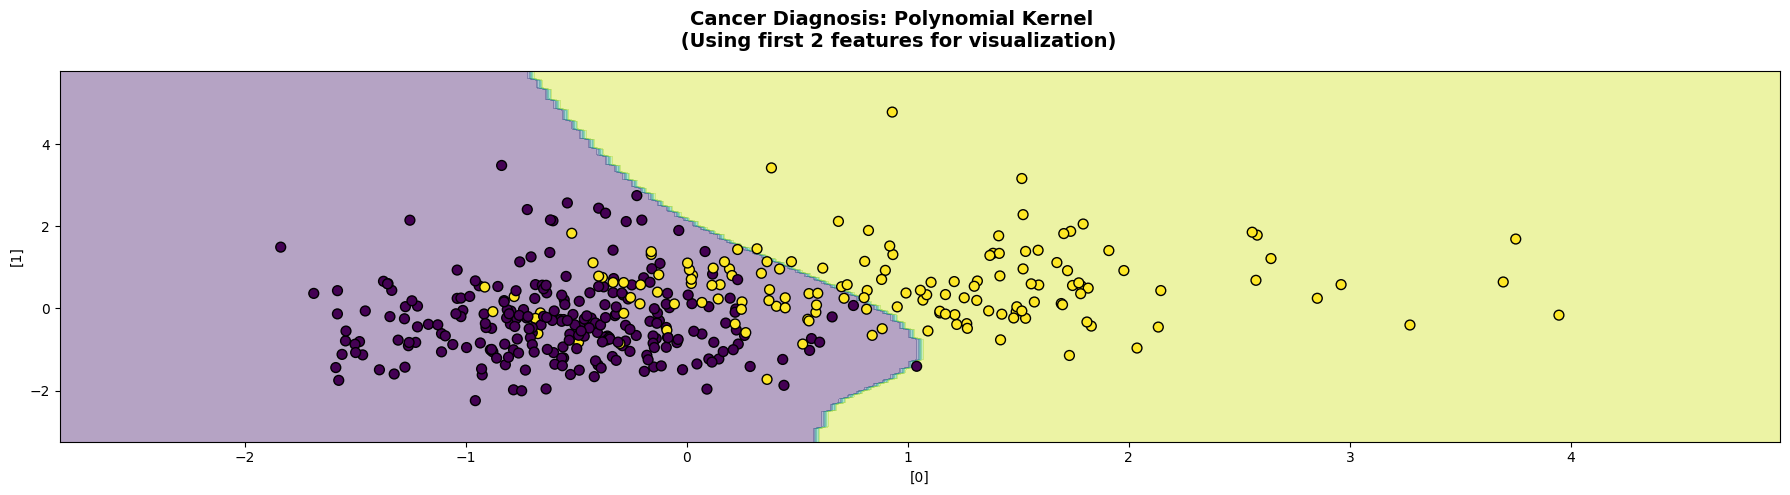

In [132]:
# Create a figure with 3 subplots (one for each kernel)
fig, axes = plt.subplots(1, figsize=(18, 5))
# List of kernels to visualize
kernels = [('poly', 'Polynomial', accuracy_poly)]
# Create mesh grid for plotting decision boundaries
# This creates a grid of points covering the entire plot area
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))
#Plotting the kernel with the scaled features
model=SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
model.fit(X_train_2d_scaled, y_train_2d)
#Showing the actual boundaries
z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
#This will just give you background color of the grid
axes.contourf(xx, yy, z, alpha=0.4, cmap='viridis')
#plotting the actual traing points
axes.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, edgecolors='k', cmap='viridis', s=50)
# adding all labels and title for the plot
#Showing the final results
axes.set_xlabel([0], fontsize=10)
axes.set_ylabel([1], fontsize=10)
plt.suptitle('Cancer Diagnosis: Polynomial Kernel \n (Using first 2 features for visualization)',
               fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show

The dataset we chose was the characteristics of patients diagnosed with cancer. The dataset contains a  the type of cancer (diagnosis), the visual characteristics of the cancer and the average values of these characteristics. We used a Support Vector Machine (SVM) with a polynomial kernel to classify cancer data as malignant or benign. By then preprocessing the features and splitting the data into training and testing sets we found that Linear was the best model to use. Instead of using a linear model, we applied a polynomial kernel to allow the SVM to capture more complex, non-linear relationships between the tumor features. After training the model, we evaluated its performance using metrics such as and view the two most important features and how well it classified each case.